In [2]:
import os
import sys
sys.path.insert(0, "/hkfs/work/workspace/scratch/cc7738-2025_whole/ANP4Link/")
import argparse
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import torch
from torch import Tensor
from scipy.sparse.linalg import eigsh
from scipy.stats import qmc
from typing import Optional
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import WLConv
from torch_geometric.typing import Adj
from torch_geometric.utils import (
    degree,
    is_sparse,
    scatter,
    sort_edge_index,
    to_edge_index,
    from_networkx
)

import matplotlib.pyplot as plt
from torch_geometric.datasets import Planetoid, Amazon
from torch_geometric.utils import train_test_split_edges, to_undirected
import random
from networkx import random_regular_graph
from syn_graph.graph_generation import GraphType 
from syn_graph.syn_random import RegularTilling
import torch
from collections import Counter
from syn_graph.syn_random import init_regular_tilling
from syn_graph.graph_generation import generate_graph, plot_triangular_graph
import matplotlib.pyplot as plt
import networkx as nx
from syn_real.custom_wl import WLConvOptimized, WLConvMultiFeature, WLConvMultiFeature, WLConvOptimized

In [3]:

def plot_graph_with_orbits(G, pos, orbits, custom_labels=None, figsize=(8, 6), cmap='tab20b'):
    """
    Plots a NetworkX graph with node coloring based on orbit labels.
    
    Parameters:
        G (nx.Graph): The graph to plot.
        pos (dict): Node positions.
        orbits (list or array): Orbit label for each node.
        custom_labels (dict, optional): Dictionary of node labels.
        figsize (tuple): Figure size for the plot.
        cmap (str): Matplotlib colormap for nodes.
    """
    plt.figure(figsize=figsize)
    node_colors = [orbits[node] for node in G.nodes()]
    nx.draw(
        G,
        pos=pos,
        labels=custom_labels,
        node_color=node_colors,
        cmap=cmap,
        node_size=500,
        font_weight='bold',
        edgecolors='black'
    )
    plt.title("Graph Colored by Orbit Labels")
    plt.show()
    plt.close()

In [4]:
def plot_orbit_dist(node_groups):
    group_sizes = np.array([len(group) for group in node_groups.values()])
    plt.figure(figsize=(6, 4))
    plt.hist(group_sizes, bins=range(min(group_sizes), max(group_sizes) + 2), align='left', rwidth=0.8)
    plt.xlabel('Orbit Label')
    plt.ylabel('Frequency')
    plt.title('Histogram of Orbit Labels')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    # plt.savefig(f"{name}_distribution_d{depth}.pdf")
    plt.close()

In [5]:
def plot_orbit(orbits):
    plt.figure(figsize=(6, 4))
    plt.hist(orbits, bins=range(min(orbits), max(orbits) + 2), align='left', rwidth=0.8)
    plt.xlabel('Orbit Label')
    plt.ylabel('Frequency')
    plt.title('Histogram of Orbit Labels')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    # plt.savefig(f"{name}_distribution_d{depth}.pdf")
    plt.close()

In [6]:

def compute_automorphism_metrics(node_groups, num_nodes):
    """
    Computes numerical metrics for graph automorphism based on WL node grouping.
    Args:
        node_groups (dict): Dictionary mapping WL hash values to lists of node indices.
        num_nodes (int): Total number of nodes in the graph.

    Returns:
        dict: Automorphism metrics {A_r1, C_auto, H_auto}
    """
    # Compute the size of each group (how many nodes share the same WL label)
    group_sizes = np.array([len(group) for group in node_groups.values()])

    A_r1 = np.sum(group_sizes**2) / num_nodes**2
    C_auto = len(node_groups)
    A_r_norm_1 = 1 + np.log(A_r1) / np.log(num_nodes) # lower is less automorphism
    A_r_norm_2 = np.log(np.sum(group_sizes**2)) / (2 * np.log(num_nodes)) 
    A_r_log = (np.log(np.sum(group_sizes**2)) - np.log(num_nodes**2)) / np.log(num_nodes)
    automorphism_score = (len(node_groups) / num_nodes)
    return {
        "Automorphism Ratio (A_r1)": A_r1,
        "A_r_norm_2": A_r_norm_2,
        "A_r_norm_1": A_r_norm_1,
        "Number of Unique Groups (C_auto)": C_auto,
        "Automorphism Ratio (A_r_log)": A_r_log,
        "num_nodes": num_nodes,
        "automorphism_score": automorphism_score
    }, num_nodes, group_sizes

In [7]:
from syn_real.custom_wl import WLConvOptimized, WLConvMultiFeature, WLConvMultiFeature, WLConvOptimized


def run_wl_test_and_group_nodes(edge_index, num_nodes, num_iterations=1000):
    """
    Runs the Weisfeiler-Lehman (WL) test and groups nodes with similar hashed labels.
    
    Args:
        edge_index (Tensor): The edge index tensor (2, |E|) representing the graph.
        num_nodes (int): The number of nodes in the graph.
        num_iterations (int): Number of WL iterations.
    
    Returns:
        node_groups (dict): Mapping from WL hashes to node sets.
        node_labels (Tensor): Final hashed labels for each node.
    """
    # wl = WLConvMultiFeature()  
    wl = WLConvOptimized()  

    node_labels = np.ones(num_nodes)
    for _ in range(num_iterations):
        node_labels = wl(node_labels, edge_index)  
    # Group nodes based on final hashed values
    node_groups = {}
    for node, label in enumerate(node_labels.tolist()):
        if label not in node_groups:
            node_groups[label] = []
        node_groups[label].append(node)
    _, new_labels = torch.unique(node_labels, return_inverse=True)
    return node_groups, node_labels, new_labels


from collections import defaultdict

def count_orbit_edges(G, node_groups):
    # Create a mapping: node -> orbit_id

    intra_orbit_edges = 0
    inter_orbit_edges = 0

    try:
        for u, v in G.edges():
            if node_groups[u] == node_groups[v]:
                intra_orbit_edges += 1
            else:
                inter_orbit_edges += 1
    except:
    
        for links in G.edges():
            for u, v in links:
                if node_groups[u] == node_groups[v]:
                    intra_orbit_edges += 1
                else:
                    inter_orbit_edges += 1
    print(f"Intra-orbit edges: {intra_orbit_edges}, Inter-orbit edges: {inter_orbit_edges}")
    return intra_orbit_edges, inter_orbit_edges



def process_graph(N, graph_type, pos=None, is_grid=False, label="graph"):
    print(f"Processing graph of type {graph_type} with {N} nodes")
    if graph_type == RegularTilling.SQUARE_GRID:
        G, _, _, pos = init_regular_tilling(N, RegularTilling.SQUARE_GRID, seed=None)
    elif graph_type == 'GraphType.COMPLETE':
        graph_type = 'GraphType.COMPLETE'
        G = nx.complete_graph(N)
    else:
        G = generate_graph(N, graph_type, seed=0)
    
    # Process Graph with WL Test
    data = from_networkx(G)
    edge_index = data.edge_index
    node_groups, node_labels, orbits = run_wl_test_and_group_nodes(edge_index, num_nodes=G.number_of_nodes(), num_iterations=100)
    metrics, num_nodes, group_sizes = compute_automorphism_metrics(node_groups, G.number_of_nodes())
    count_orbit_edges(G, node_labels)
    
    try:
        custom_labels = {}
        for i, ov in zip(G.nodes(), orbits):
                custom_labels[i] = f"{ov}"

        plot_graph_with_orbits(G, pos, orbits, custom_labels=custom_labels, figsize=(8, 6), cmap='tab20b')
        plot_orbit_dist(node_groups)
        plot_orbit(orbits)
    except:
        # Visualiz  e with WL-based coloring
        plot_triangular_graph(G, orbits, custom_labels=node_labels, figsize=(8, 6), cmap='tab20b')
        plot_orbit_dist(node_groups)
        plot_orbit(orbits)
    # save_metrics(metrics, f"{graph_type}_{N}", csv_path='summary.csv'

Processing graph of type GraphType.BARABASI_ALBERT with 10 nodes
Intra-orbit edges: 0, Inter-orbit edges: 16


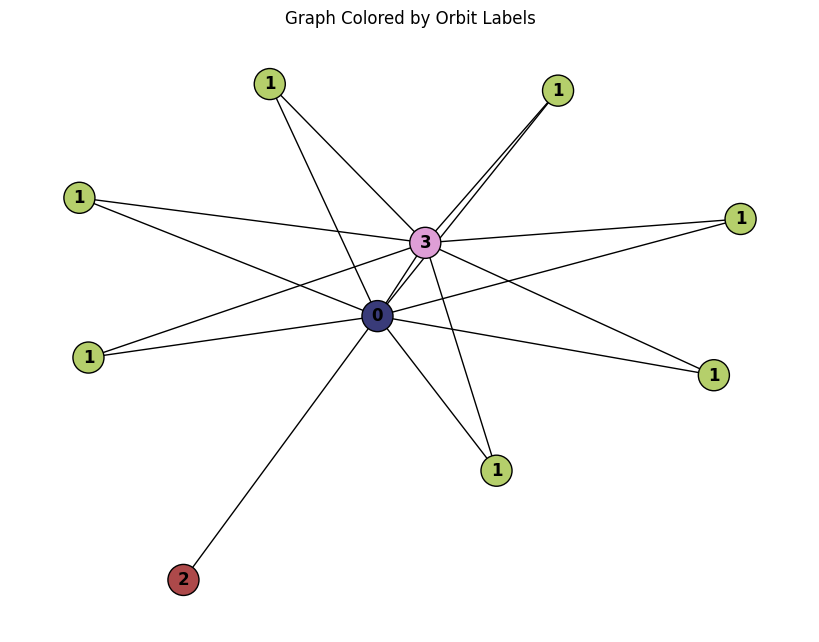

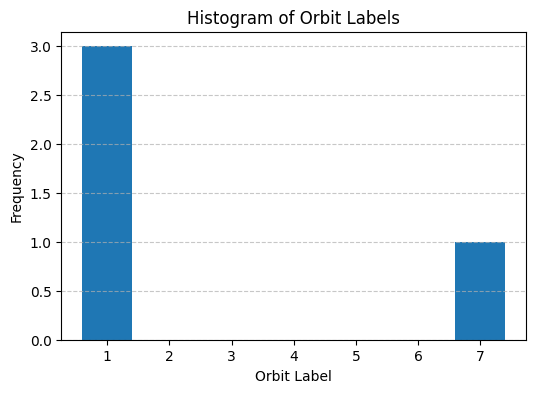

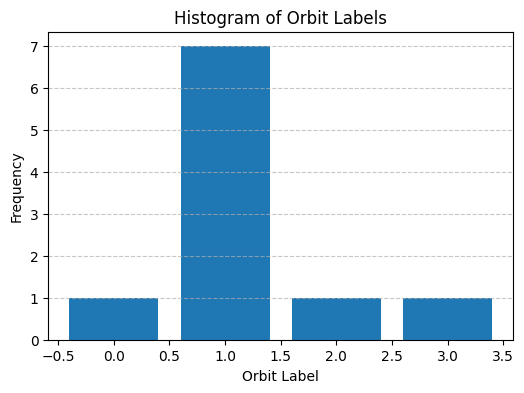

In [8]:
process_graph(10, GraphType.BARABASI_ALBERT)

 

Processing graph of type GraphType.BARABASI_ALBERT with 20 nodes
Intra-orbit edges: 0, Inter-orbit edges: 51


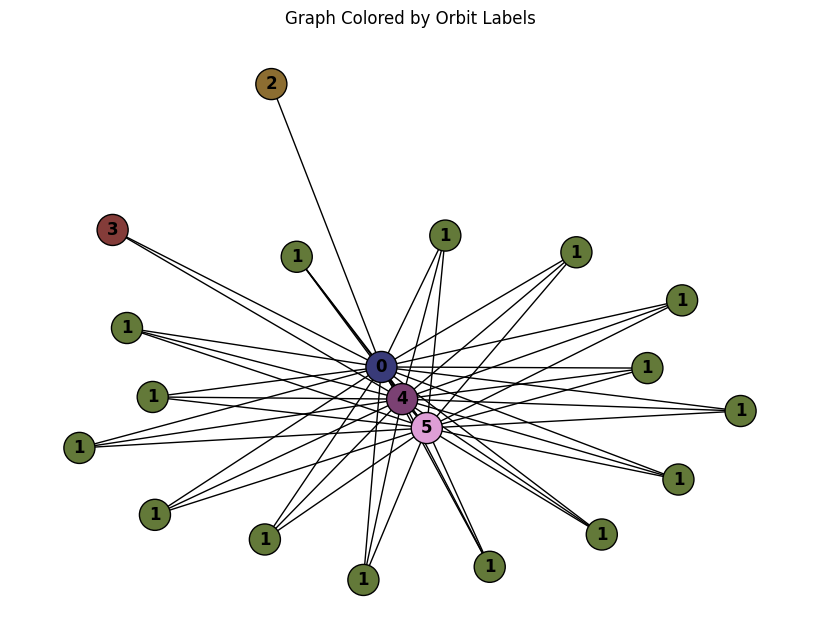

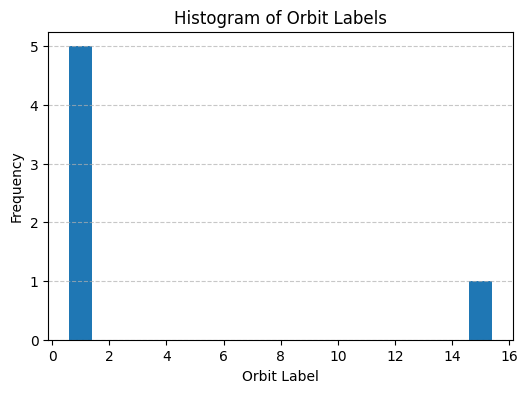

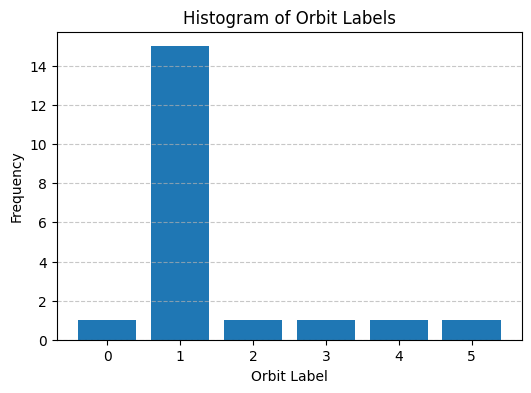

In [9]:
process_graph(20, GraphType.BARABASI_ALBERT)

Processing graph of type GraphType.BARABASI_ALBERT with 40 nodes
Intra-orbit edges: 0, Inter-orbit edges: 231


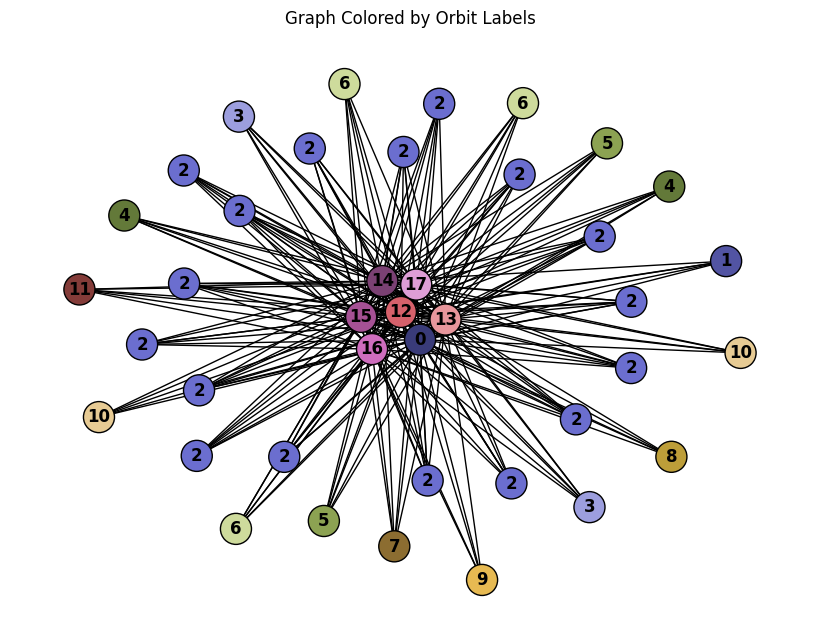

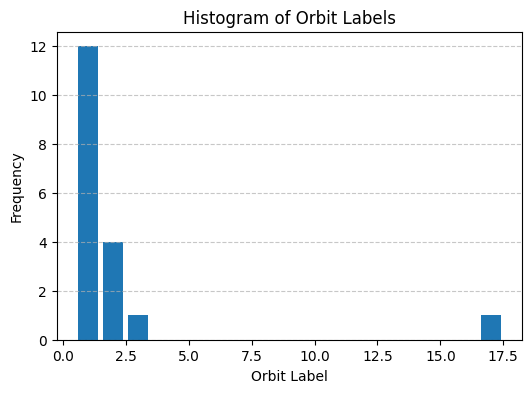

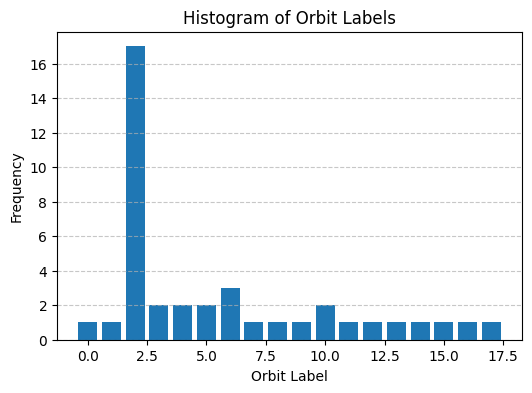

In [10]:
process_graph(40, GraphType.BARABASI_ALBERT)

Processing graph of type GraphType.BARABASI_ALBERT with 60 nodes
Intra-orbit edges: 0, Inter-orbit edges: 500


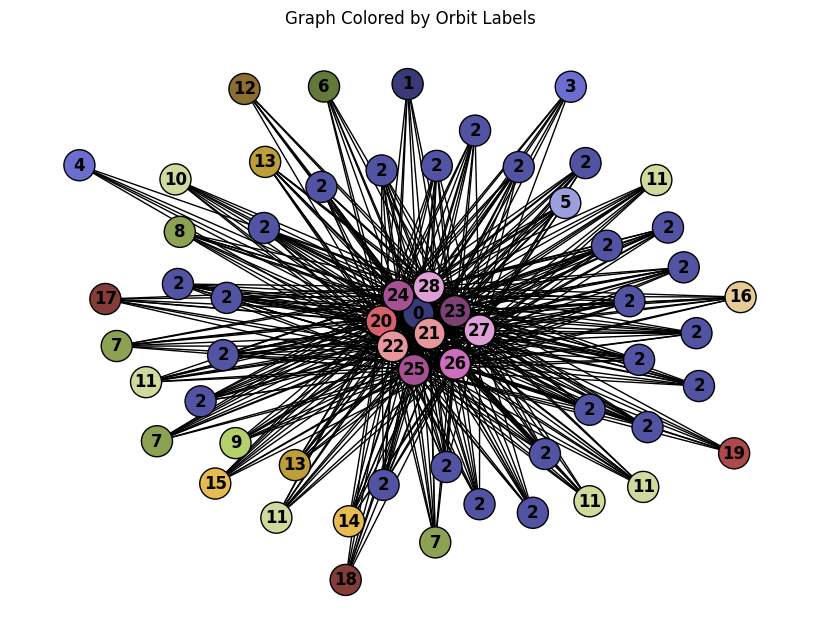

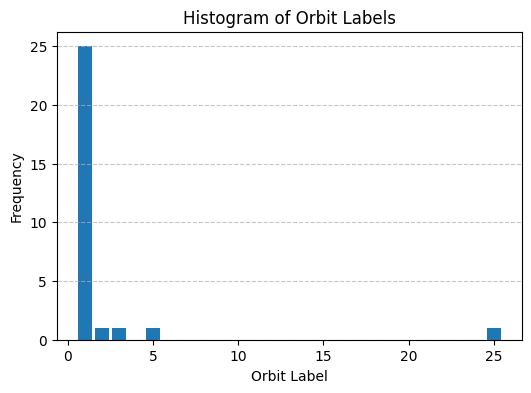

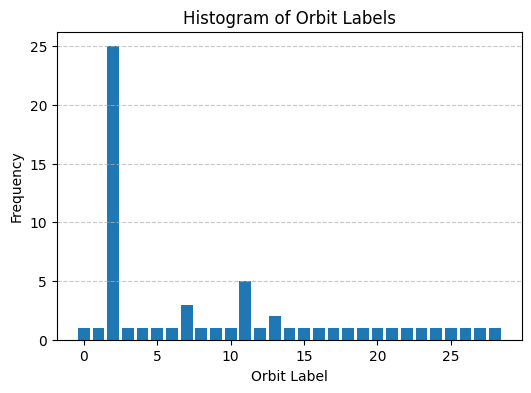

In [11]:
process_graph(60, GraphType.BARABASI_ALBERT)

Processing graph of type GraphType.TREE with 34 nodes
Intra-orbit edges: 0, Inter-orbit edges: 33


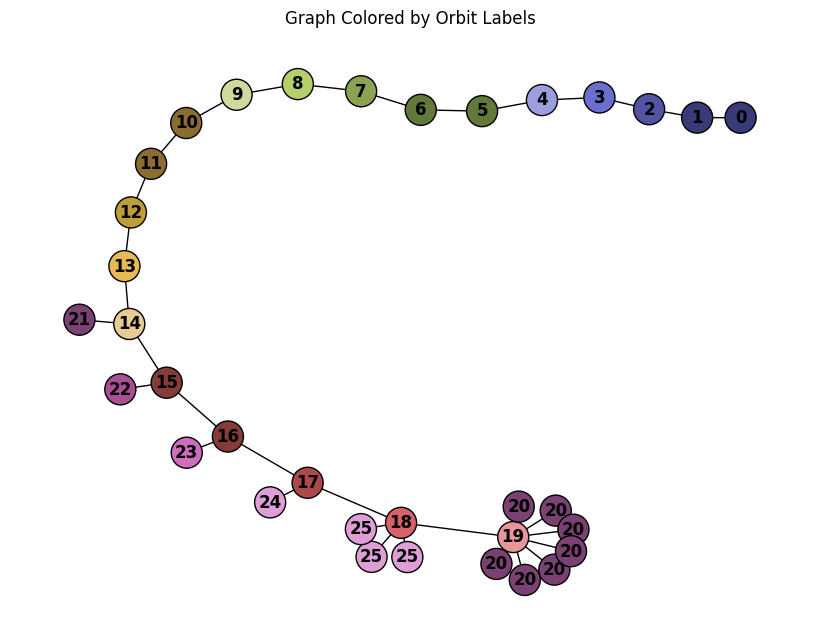

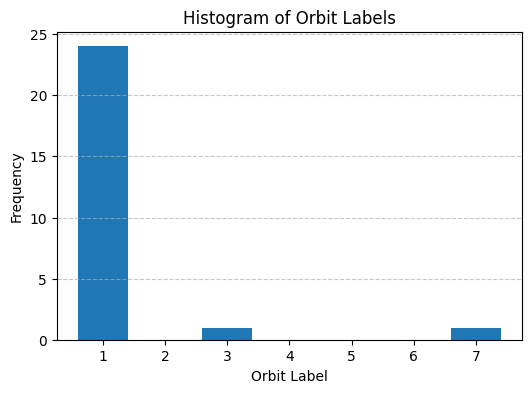

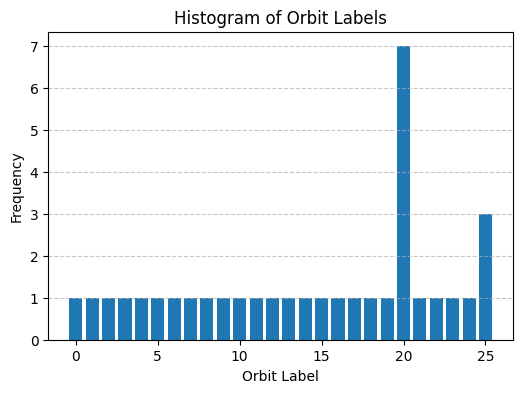

In [12]:
process_graph(34, GraphType.TREE)

Processing graph of type GraphType.TREE with 10 nodes
Intra-orbit edges: 0, Inter-orbit edges: 9


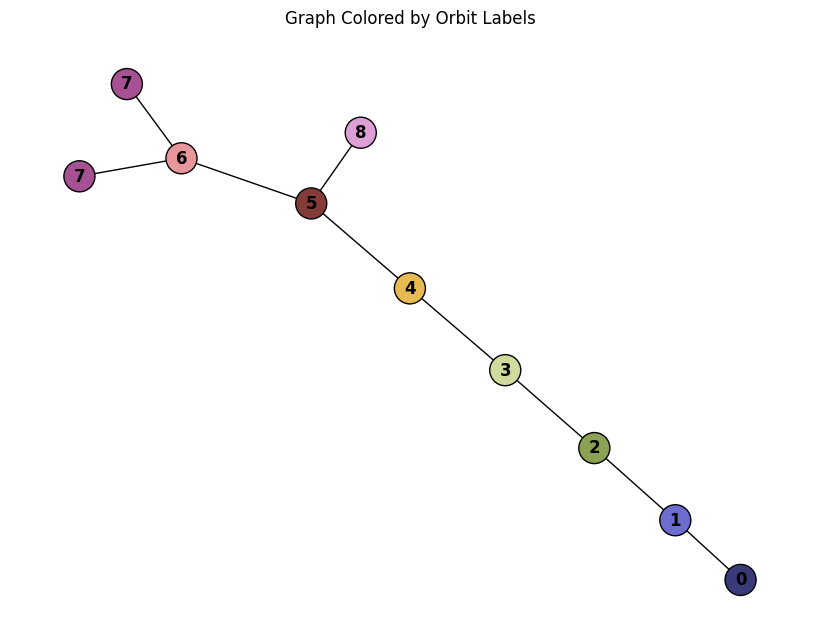

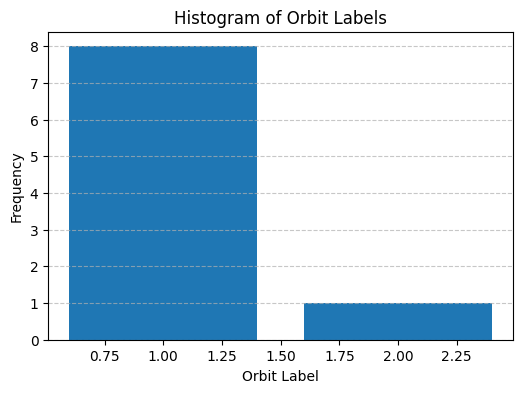

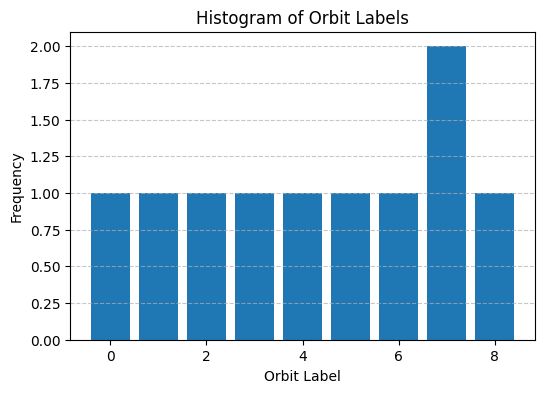

In [13]:
process_graph(10, GraphType.TREE)

Processing graph of type RegularTilling.SQUARE_GRID with 10 nodes
Intra-orbit edges: 20, Inter-orbit edges: 160


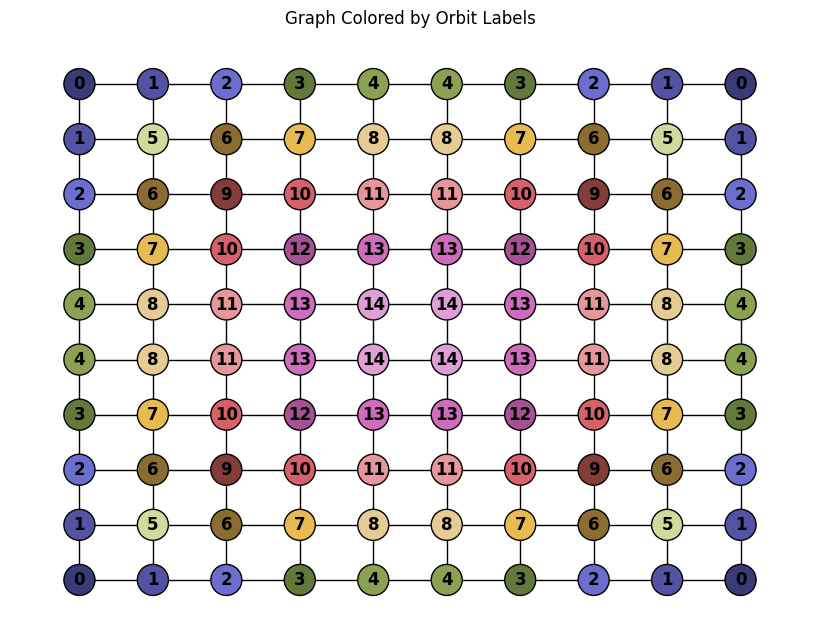

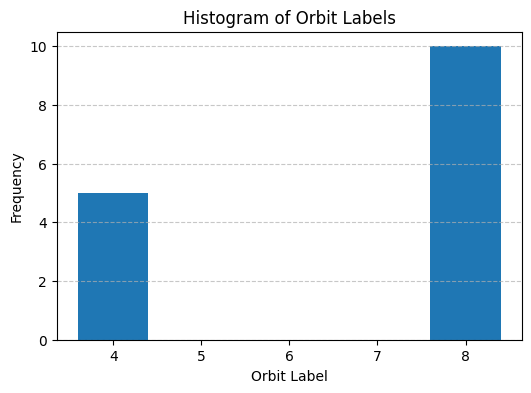

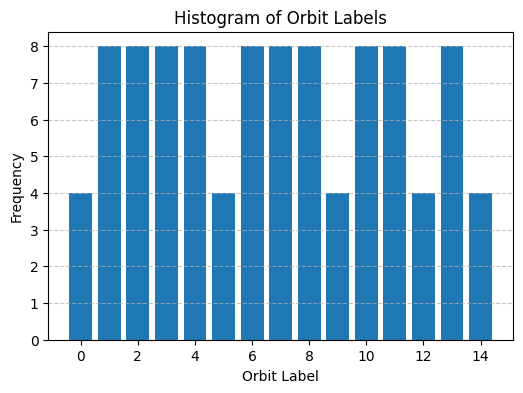

Processing graph of type RegularTilling.SQUARE_GRID with 20 nodes
Intra-orbit edges: 40, Inter-orbit edges: 720


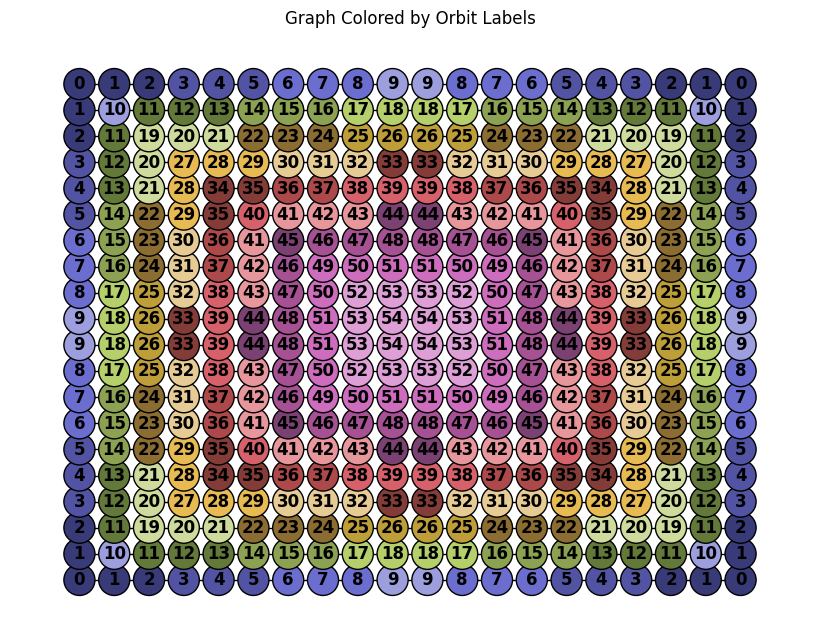

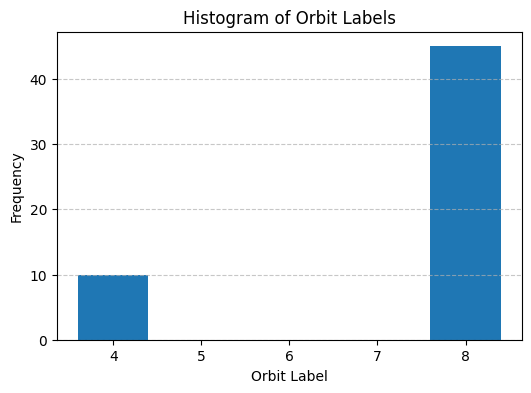

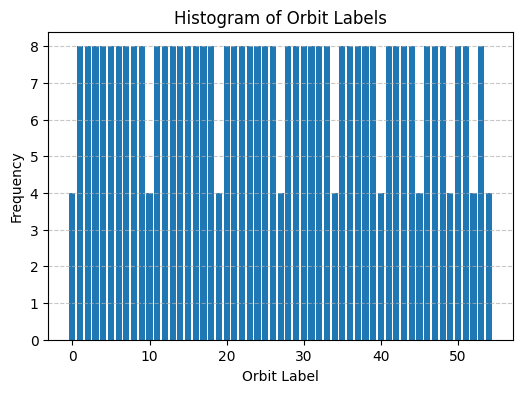

Processing graph of type RegularTilling.SQUARE_GRID with 80 nodes
Intra-orbit edges: 160, Inter-orbit edges: 12480


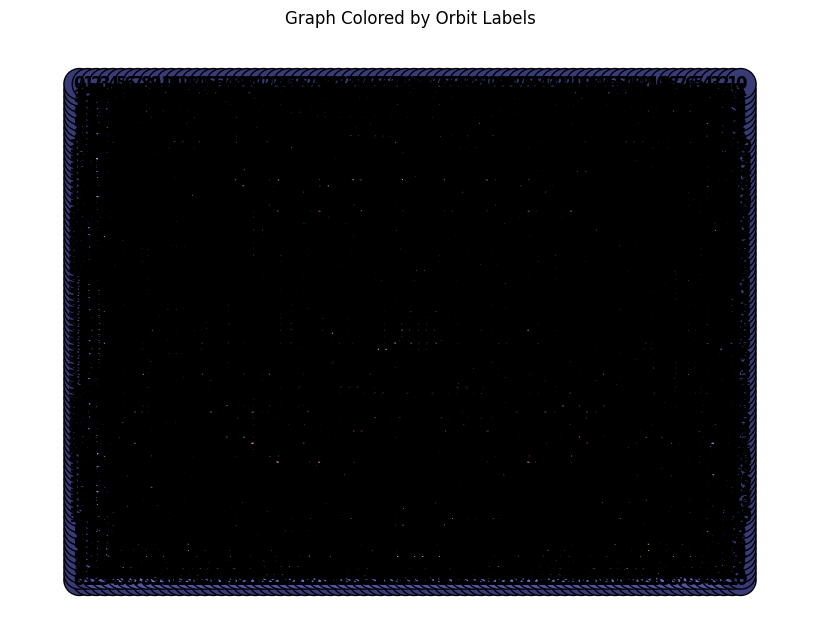

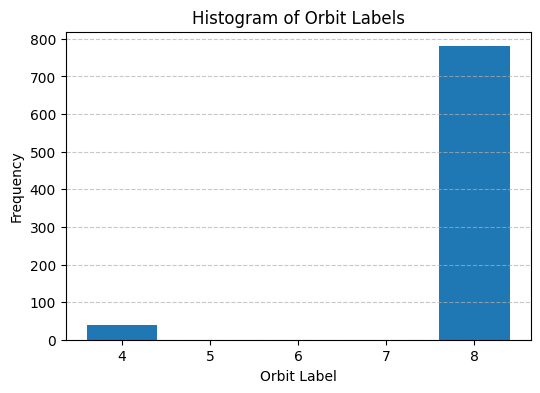

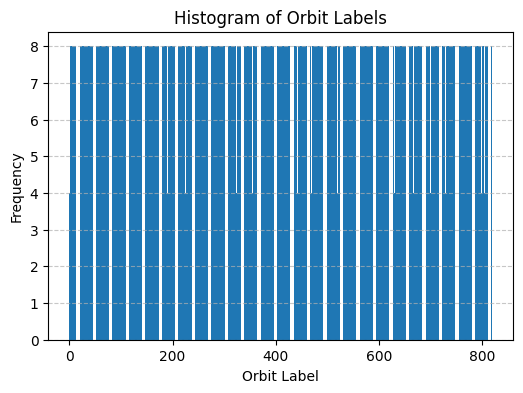

Processing graph of type GraphType.TRIANGULAR with 10 nodes
Intra-orbit edges: 23, Inter-orbit edges: 17


/hkfs/work/workspace/scratch/cc7738-2025_whole/ANP4Link/syn_graph/graph_generation.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 800x600 with 0 Axes>

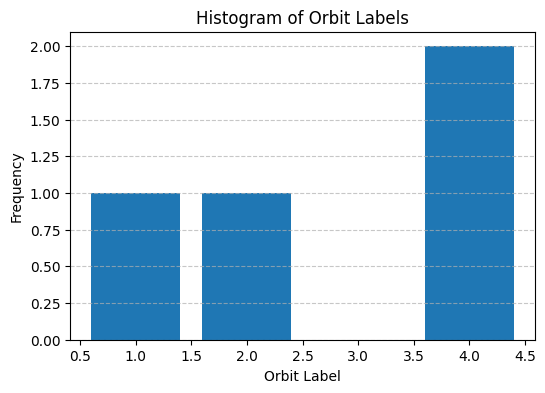

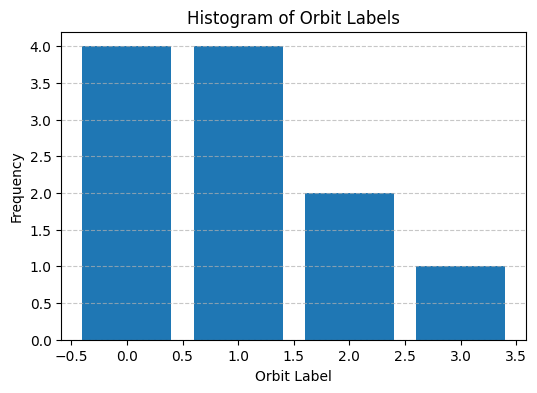

Processing graph of type GraphType.TRIANGULAR with 20 nodes
Intra-orbit edges: 32, Inter-orbit edges: 42


/hkfs/work/workspace/scratch/cc7738-2025_whole/ANP4Link/syn_graph/graph_generation.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 800x600 with 0 Axes>

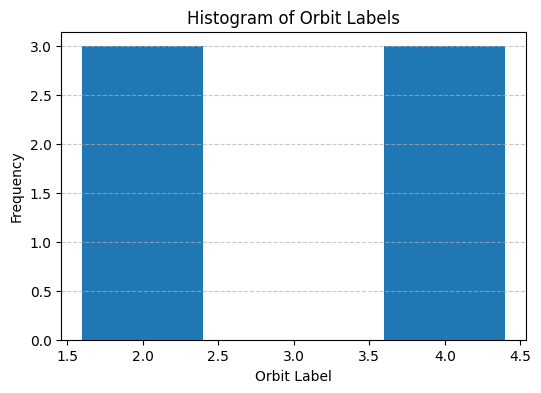

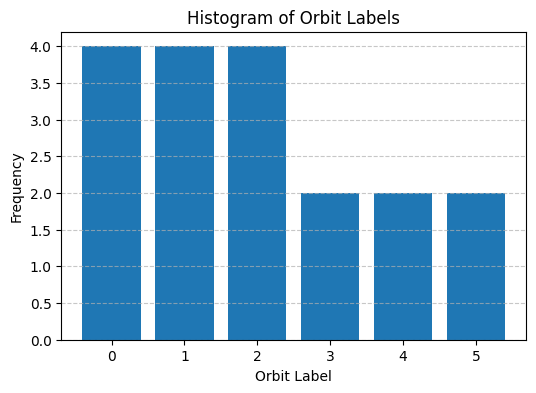

Processing graph of type GraphType.TRIANGULAR with 30 nodes
Intra-orbit edges: 17, Inter-orbit edges: 89


/hkfs/work/workspace/scratch/cc7738-2025_whole/ANP4Link/syn_graph/graph_generation.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 800x600 with 0 Axes>

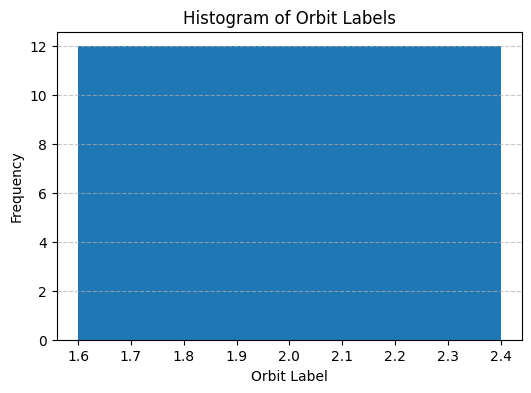

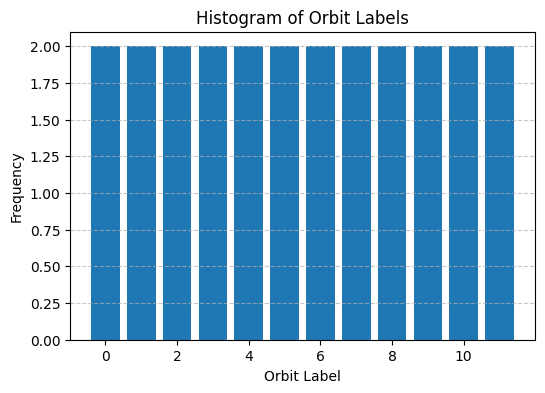

In [14]:
process_graph(10, RegularTilling.SQUARE_GRID)


process_graph(20, RegularTilling.SQUARE_GRID)


process_graph(80, RegularTilling.SQUARE_GRID)


process_graph(10, GraphType.TRIANGULAR)


process_graph(20, GraphType.TRIANGULAR)


process_graph(30, GraphType.TRIANGULAR)

Processing graph of type GraphType.ERDOS_RENYI with 10 nodes
Intra-orbit edges: 0, Inter-orbit edges: 35


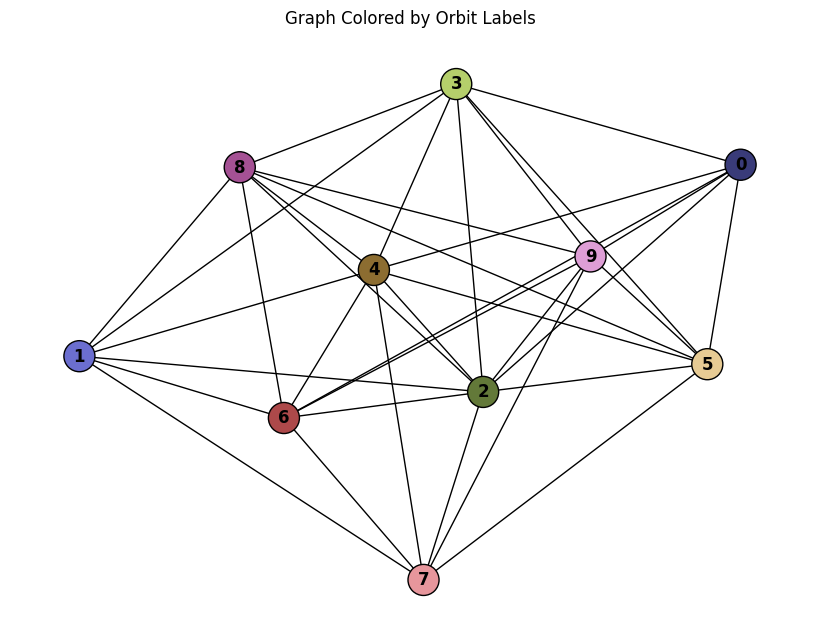

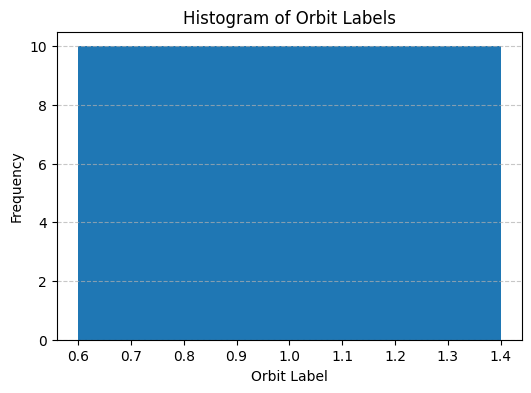

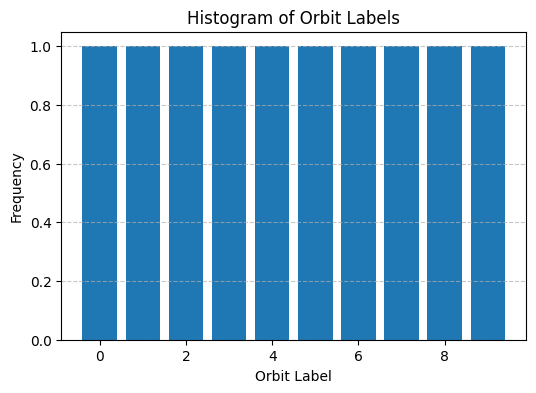

In [15]:
process_graph(10, GraphType.ERDOS_RENYI)